<a href="https://colab.research.google.com/github/elenadaniels85-glitch/CUNY-Data-Analytics/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
#This data includes NYC restaurant inspection results for active restaurants for the last few years
df = pd.read_csv("https://data.cityofnewyork.us/resource/43nn-pn8j.csv?$limit=300000")

/tmp/ipykernel_678/2760122148.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://data.cityofnewyork.us/resource/43nn-pn8j.csv?$limit=300000")


Objective:
- Analyze restaurant inspection outcomes accross NYC from 2023 to 2025
- Identify patterns in violation severety, cuisine type, and grading
- Evaluate whether inspection grades reflect actual food safety risk

In [6]:
df.shape

(296201, 27)

In [7]:
df.head()

,camis,dba,boro,building,street,zipcode,phone,cuisine_description,inspection_date,action,...,inspection_type,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,location
0,50176328,3 LUIGIS PIZZERIA,Brooklyn,275,GRAND AVENUE,11238.0,7186220059,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.688123,-73.962741,302.0,35.0,23100.0,3055567.0,3.019480e+09,BK69,POINT (-73.962741121417 40.688123259564)
1,50182935,Savour,Manhattan,3360,BROADWAY,10031.0,6462077989,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.820541,-73.954736,109.0,7.0,22301.0,1059810.0,1.019880e+09,MN06,POINT (-73.954736122649 40.820541306275)
2,50158161,FRIDA'S FAVORITES CHURROS AND EMPANADAS,Manhattan,42,WEST 42 STREET,10036.0,6462728190,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.754068,-73.982321,105.0,4.0,8400.0,1000000.0,1.012570e+09,MN17,POINT (-73.982321170752 40.754068239421)
3,50154813,KAPPO SONO,Manhattan,39,EAST 13 STREET,10003.0,6468995891,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.734395,-73.991932,102.0,2.0,6100.0,1009213.0,1.005650e+09,MN23,POINT (-73.991931779136 40.734394861981)
4,50155563,PHOENIX,Manhattan,447,EAST 13 STREET,10009.0,3472812503,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.730208,-73.982003,103.0,2.0,3400.0,1006022.0,1.004410e+09,MN22,POINT (-73.982002796266 40.73020796737)


In [8]:
df.tail()

,camis,dba,boro,building,street,zipcode,phone,cuisine_description,inspection_date,action,...,inspection_type,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,location
296196,50066146,PINK FOREST,Queens,72-01,AUSTIN STREET,11375.0,6462878862.0,Coffee/Tea,2024-03-19T00:00:00.000,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Initial Inspection,40.719281,-73.842460,406.0,29.0,73700.0,4078033.0,4.032580e+09,QN17,POINT (-73.842460112112 40.719281308702)
296197,40526104,AMY'S BREAD,Manhattan,75,NINTH AVENUE,10011.0,2124624338.0,Bakery Products/Desserts,2025-01-02T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.741869,-74.004713,104.0,3.0,8300.0,1012541.0,1.007130e+09,MN13,POINT (-74.004713006739 40.741869040229)
296198,41503108,TULCINGO RESTAURANT,Queens,40364040,NATIONAL STREET,NaN,7186398880.0,Mexican,2023-01-19T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,4.000000e+00,NaN,NaN
296199,50122496,LITTLE GEM CATERING + EVENTS,Manhattan,345,EAST 62 STREET,10065.0,9175397116.0,American,2023-12-13T00:00:00.000,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Initial Inspection,40.761891,-73.961555,108.0,5.0,11000.0,1044365.0,1.014370e+09,MN31,POINT (-73.961555382702 40.76189121456)
296200,50090701,GAI CHICKEN & RICE,Manhattan,158,EAST 45 STREET,10017.0,9176756642.0,Thai,2025-07-10T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.753035,-73.973897,106.0,4.0,9200.0,1036180.0,1.012990e+09,MN19,POINT (-73.973897243235 40.753034602556)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296201 entries, 0 to 296200
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   camis                  296201 non-null  int64  
 1   dba                    296199 non-null  object 
 2   boro                   296201 non-null  object 
 3   building               295265 non-null  object 
 4   street                 296183 non-null  object 
 5   zipcode                293110 non-null  float64
 6   phone                  296111 non-null  object 
 7   cuisine_description    292705 non-null  object 
 8   inspection_date        296201 non-null  object 
 9   action                 292811 non-null  object 
 10  violation_code         290421 non-null  object 
 11  violation_description  290421 non-null  object 
 12  critical_flag          296201 non-null  object 
 13  score                  279209 non-null  float64
 14  grade                  146197 non-nu

In [10]:
#To keep only necessary columns
subset1 = df[['camis', 'boro', 'cuisine_description', 'inspection_date', 'violation_description', 'critical_flag', 'grade', 'grade_date']]

In [11]:
#To rename some columns for clarity
subset1 = subset1.rename(columns={
    'camis': 'restaurant_id',
    'critical_flag': 'violation_class'
})

In [12]:
subset1.head()

,restaurant_id,boro,cuisine_description,inspection_date,violation_description,violation_class,grade,grade_date
0,50176328,Brooklyn,NaN,1900-01-01T00:00:00.000,NaN,Not Applicable,NaN,NaN
1,50182935,Manhattan,NaN,1900-01-01T00:00:00.000,NaN,Not Applicable,NaN,NaN
2,50158161,Manhattan,NaN,1900-01-01T00:00:00.000,NaN,Not Applicable,NaN,NaN
3,50154813,Manhattan,NaN,1900-01-01T00:00:00.000,NaN,Not Applicable,NaN,NaN
4,50155563,Manhattan,NaN,1900-01-01T00:00:00.000,NaN,Not Applicable,NaN,NaN


In [14]:
subset1['boro'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', '0', 'Staten Island', 'Bronx'],
      dtype=object)

Data cleaning: remove placeholder inspection dates, i.e. dates where inspection has not yet been completed as well as records where borough of restaurant location is not identified

In [16]:
#To exclude records where 'inspection_date' is '1900-01-01T00:00:00.000', i.e. where inspection has NOT yet been completed
#and where borough is not identified
subset2 = subset1[(subset1['inspection_date'] != '1900-01-01T00:00:00.000') & (subset1['boro'] != '0')]
subset2.shape

(292238, 8)

In [17]:
#To drop the timestamp and keep only the date for inspection_date variable
#First, convert the object type to datetime
subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date'])
subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date']).dt.normalize()
subset2['inspection_date'].info()

<class 'pandas.core.series.Series'>
Index: 292238 entries, 13 to 296200
Series name: inspection_date
Non-Null Count   Dtype         
--------------   -----         
292238 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 4.5 MB


/tmp/ipykernel_678/1697290084.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date'])
/tmp/ipykernel_678/1697290084.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['inspection_date'] = pd.to_datetime(subset2['inspection_date']).dt.normalize()


In [18]:
subset2['inspection_date']

,inspection_date
13,2025-07-07
14,2025-07-17
16,2025-06-26
17,2022-11-29
28,2024-08-28
...,...
296196,2024-03-19
296197,2025-01-02
296198,2023-01-19
296199,2023-12-13


In [19]:
#to extract year into a separate column
subset2['inspection_year'] = subset2['inspection_date'].dt.year
subset2.head(5)

/tmp/ipykernel_678/2034877709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['inspection_year'] = subset2['inspection_date'].dt.year


,restaurant_id,boro,cuisine_description,inspection_date,violation_description,violation_class,grade,grade_date,inspection_year
13,50040448,Queens,Donuts,2025-07-07,Thawing procedure improper.,Not Critical,A,2025-07-07T00:00:00.000,2025
14,41063300,Queens,Italian,2025-07-17,Live roaches in facility's food or non-food area.,Critical,B,2025-07-17T00:00:00.000,2025
16,50112427,Brooklyn,Japanese,2025-06-26,Establishment is not free of harborage or cond...,Not Critical,NaN,NaN,2025
17,40659101,Brooklyn,Chinese,2022-11-29,Hot TCS food item not held at or above 140 °F.,Critical,B,2022-11-29T00:00:00.000,2022
28,41347625,Queens,Sandwiches,2024-08-28,Food Protection Certificate (FPC) not held by ...,Critical,A,2024-08-28T00:00:00.000,2024


<Axes: xlabel='inspection_year'>

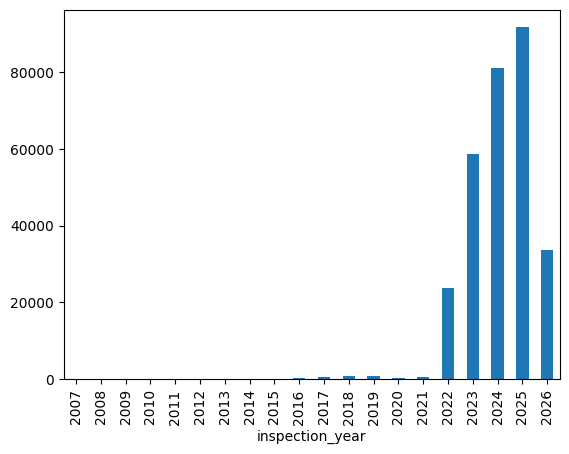

In [20]:
#to return how many inspections conducted per year
year_counts = subset2.groupby(subset2['inspection_year']).size()
year_counts.plot(kind='bar')

In [21]:
#to focus only on the last 3 years (as these years appear to have most complete data) - remove all years other than 2023, 2024, 2025
subset3 = subset2[subset2['inspection_year'].isin([2023, 2024, 2025])]

In [22]:
#how many unique restaurant ID's in the data set - this is how many restaurants were inspected over last 3 subject years
subset3['restaurant_id'].nunique()

25782

In [23]:
subset3['cuisine_description'].unique()

array(['Donuts', 'Italian', 'Japanese', 'Sandwiches', 'Chinese',
       'Latin American', 'Bagels/Pretzels', 'African', 'Coffee/Tea',
       'American', 'Mexican', 'Hotdogs', 'Vegetarian', 'Thai', 'Spanish',
       'Vegan', 'Asian/Asian Fusion', 'Iranian', 'Indian', 'Caribbean',
       'Other', 'Tex-Mex', 'Pizza', 'Seafood', 'French', 'Hamburgers',
       'Soul Food', 'Mediterranean', 'Continental', 'Chicken',
       'Jewish/Kosher', 'Bakery Products/Desserts', 'Eastern European',
       'Middle Eastern', 'Ethiopian', 'Hawaiian', 'Polish',
       'Southeast Asian', 'Salads', 'Brazilian', 'Filipino',
       'Sandwiches/Salads/Mixed Buffet', 'Creole', 'Barbecue', 'Peruvian',
       'Korean', 'Juice, Smoothies, Fruit Salads', 'Fusion', 'Armenian',
       'Lebanese', 'Irish', 'Hotdogs/Pretzels', 'Bangladeshi',
       'Pakistani', 'Steakhouse', 'Turkish', 'Greek', 'Chinese/Cuban',
       'Indonesian', 'New American', 'Frozen Desserts', 'Basque',
       'Soups/Salads/Sandwiches', 'Pancakes/W

In [24]:
#How many different cuisines - reveals how many cuisines NYC has to offer
subset3['cuisine_description'].nunique()

90

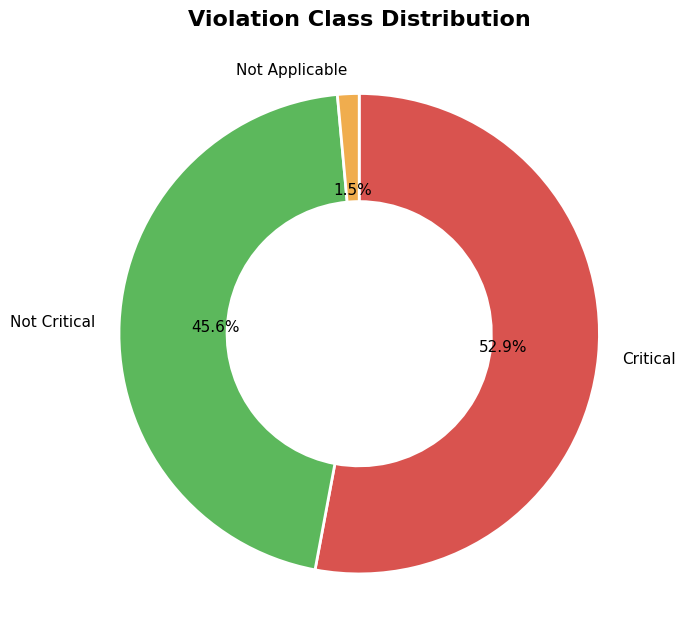

In [25]:
#critical violations are those most likely to contribute to foodborne illness, i.e. food poisoniing
#this pie chart shows the count as a percentage of the total
critical_percentages = (
    subset3['violation_class']
    .value_counts(normalize=True)
    .mul(100)
)

colors = ['#d9534f', '#5cb85c', '#f0ad4e']

plt.figure(figsize=(7, 7))

critical_percentages.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2,
        'width': 0.45
    },
    textprops={'fontsize': 11}
)

plt.title('Violation Class Distribution', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()
#Insight: isntances where no violations were cited at the time of inspection are very rare!
#there is a 50-50 chance that that restaurant has critical violations which by definition may lead to you getting food poisoning

In [26]:
# Examples of critical_class violtions: Live roaches in facility's food or non-food area, Hot food item not maintained at proper temperature,

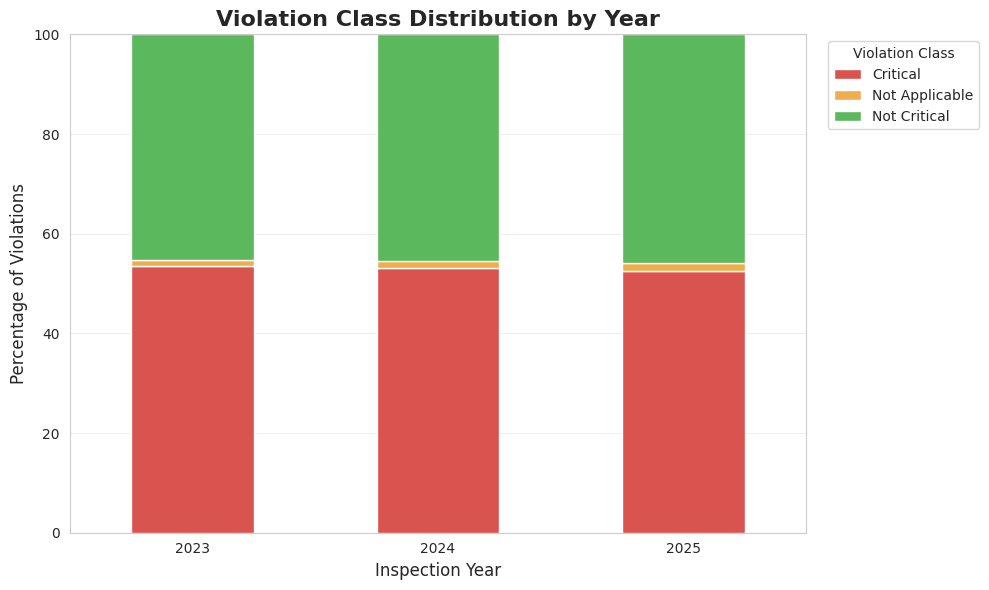

In [32]:
#aggregate by year

yearly_pct = (
    subset3
    .groupby(['inspection_year', 'violation_class'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack()
)

colors = {
    'Critical': '#d9534f',
    'Not Critical': '#5cb85c',
    'Not Applicable': '#f0ad4e'
}

ax = yearly_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=[colors[col] for col in yearly_pct.columns],
    edgecolor='white'
)

plt.title('Violation Class Distribution by Year', fontsize=16, fontweight='bold')
plt.xlabel('Inspection Year', fontsize=12)
plt.ylabel('Percentage of Violations', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(
    title='Violation Class',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

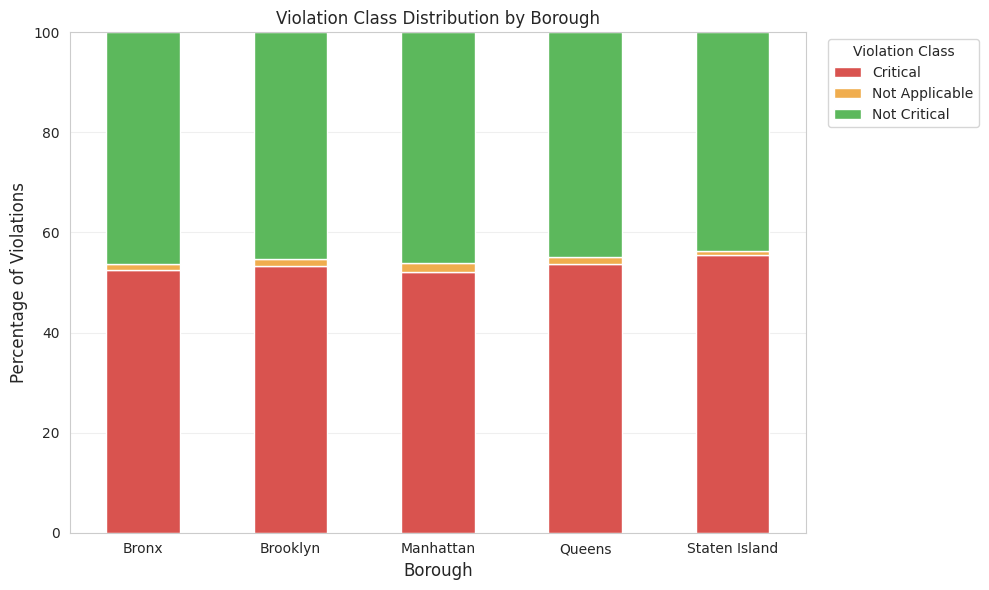

In [33]:
boro_pct = (
    subset3
    .groupby(['boro', 'violation_class'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack()
)

colors = {
    'Critical': '#d9534f',       # red
    'Not Critical': '#5cb85c',   # green
    'Not Applicable': '#f0ad4e'  # orange
}

ax = boro_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=[colors[col] for col in boro_pct.columns],
    edgecolor='white'
)

#plt.title('Violation Class Distribution by Borough', fontsize=16, fontweight='bold')
plt.xlabel('Borough', fontsize=12)
plt.title('Violation Class Distribution by Borough')
plt.ylabel('Percentage of Violations', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(
    title='Violation Class',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
#would like to return the top 10 cuisines with the lowest rate of critical violations
#1st step: Calculate critical violation rate per cuisine
cuisine_rates = (
    subset3
    .groupby('cuisine_description')['violation_class']
    .apply(lambda x: (x == 'Critical').mean() * 100)
    .reset_index(name='critical_rate')
)

In [35]:
#step 2: filter by minimum inspections (more than 10)
#This avoids something like:
#Cuisine A → 1 inspection, 0 critical → looks “perfect” (misleading)
counts = subset3['cuisine_description'].value_counts()
cuisine_rates = cuisine_rates[
    cuisine_rates['cuisine_description'].isin(counts[counts >= 15].index)
]

In [38]:
top10_lowest = cuisine_rates.sort_values('critical_rate').head(10)

print(top10_lowest)

        cuisine_description  critical_rate
62       Nuts/Confectionary      26.666667
46                  Iranian      36.363636
14              Californian      45.112782
39               Hamburgers      45.173520
35        Fruits/Vegetables      45.454545
85                  Tex-Mex      45.886889
72                   Salads      45.960265
79  Soups/Salads/Sandwiches      46.226415
42                  Hotdogs      46.666667
27                   Donuts      46.807992


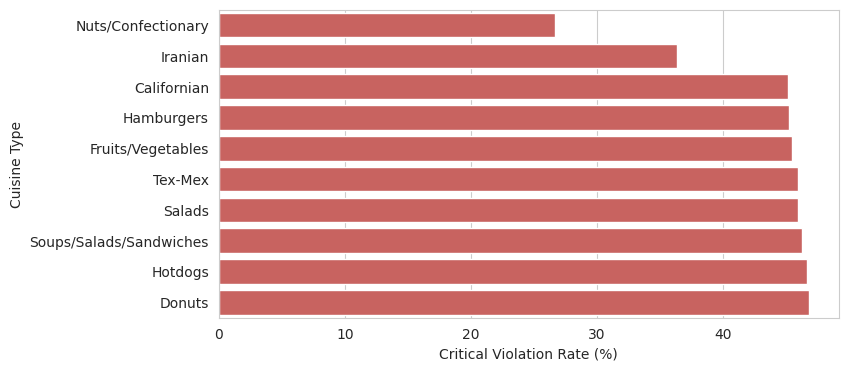

In [39]:
#to visualize
plt.figure(figsize=(8,4),)

sns.barplot(
    data=top10_lowest,
    x='critical_rate',
    y='cuisine_description',
    color='#d9534f'
)

#plt.title('10 Cuisine Types with Lowest Critical Violation Rate')
plt.xlabel('Critical Violation Rate (%)')
plt.ylabel('Cuisine Type')

plt.show()

#looks like it is best to go for nuts and candy when you are hungry!

In [40]:
subset3.shape

(231389, 9)

In [41]:
#group by grade
subset3.groupby(['grade']).size()

,0
grade,
A,78103
B,16231
C,11985
N,5543
P,696
Z,1849


In [45]:
#to filter out any records where the grade is pending (i.e N, P, or Z ) and violation class is other than critical
subset4 = subset3[((subset3['grade'] == 'A') | (subset3['grade'] == 'B') | (subset3['grade'] == 'C')) & (subset3["violation_class"] == 'Critical')]
subset4.shape


(52630, 9)

In [46]:
subset4.head()

,restaurant_id,boro,cuisine_description,inspection_date,violation_description,violation_class,grade,grade_date,inspection_year
14,41063300,Queens,Italian,2025-07-17,Live roaches in facility's food or non-food area.,Critical,B,2025-07-17T00:00:00.000,2025
28,41347625,Queens,Sandwiches,2024-08-28,Food Protection Certificate (FPC) not held by ...,Critical,A,2024-08-28T00:00:00.000,2024
106,41248866,Manhattan,African,2025-05-08,Hot TCS food item not held at or above 140 °F.,Critical,A,2025-05-08T00:00:00.000,2025
132,50001856,Manhattan,Donuts,2025-01-30,Evidence of mice or live mice in establishment...,Critical,A,2025-01-30T00:00:00.000,2025
145,50047418,Manhattan,African,2025-01-28,Evidence of rats or live rats in establishment...,Critical,C,2025-01-28T00:00:00.000,2025


In [47]:
#group by grade and violation class
subset4.groupby(['grade', 'violation_class']).size()

,,0
grade,violation_class,
A,Critical,34840
B,Critical,10090
C,Critical,7700


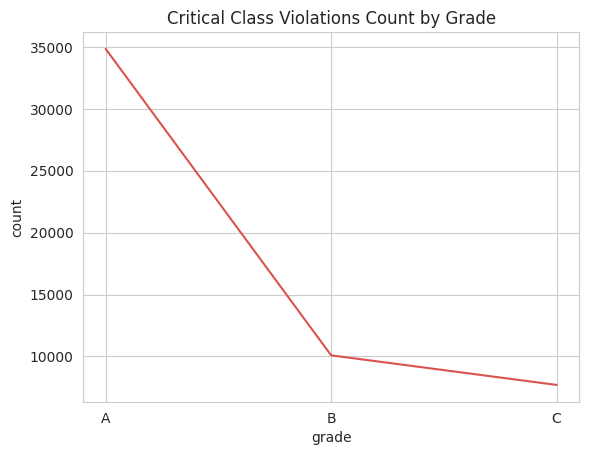

In [51]:
# Count the sizes and reset index to turn Series into DataFrame
grade_plot = subset4.groupby(['grade', 'violation_class']).size().reset_index(name='count')

# Create the grouped line plot
sns.lineplot(data=grade_plot, x='grade', y='count', color='#d9534f')
plt.title('Critical Class Violations Count by Grade')
plt.show()

#Insight: this is the maain finding - grade A restaurants have the highest number of critical violaitons!

Summary of findings:

- Most inspections result in at least one violation
- Critical violations occur in about 50% of inspections
- Patterns consistent accross boroughs and years
- Food safety challenges are not dependent on cuisne types
- Grade A does not guarantee food safety!

